<a href="https://www.kaggle.com/code/touhid20/predict-calorie?scriptVersionId=242983658" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error,mean_squared_log_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor


In [2]:
df_train=pd.read_csv('/kaggle/input/playground-series-s5e5/train.csv')
df_train.drop(columns=['id'],inplace=True)
df_train.head(10)



,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,female,38,166.0,61.0,25.0,102.0,40.6,146.0
5,female,26,156.0,56.0,19.0,100.0,40.5,103.0
6,female,21,172.0,73.0,3.0,81.0,38.3,9.0
7,male,46,188.0,94.0,23.0,100.0,40.8,145.0
8,female,33,166.0,63.0,25.0,107.0,40.5,161.0
9,male,65,185.0,88.0,23.0,104.0,41.0,185.0


In [3]:
df_test=pd.read_csv('/kaggle/input/playground-series-s5e5/test.csv')
df_test.drop(columns=['id'],inplace=True)
df_test.head(10)

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,male,45,177.0,81.0,7.0,87.0,39.8
1,male,26,200.0,97.0,20.0,101.0,40.5
2,female,29,188.0,85.0,16.0,102.0,40.4
3,female,39,172.0,73.0,20.0,107.0,40.6
4,female,30,173.0,67.0,16.0,94.0,40.5
5,female,43,169.0,65.0,6.0,81.0,39.4
6,male,74,189.0,97.0,9.0,86.0,40.0
7,male,60,186.0,90.0,2.0,79.0,38.1
8,male,21,196.0,91.0,4.0,84.0,38.7
9,male,32,189.0,89.0,29.0,111.0,40.8


In [4]:
df_train.info(),df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Sex         750000 non-null  object 
 1   Age         750000 non-null  int64  
 2   Height      750000 non-null  float64
 3   Weight      750000 non-null  float64
 4   Duration    750000 non-null  float64
 5   Heart_Rate  750000 non-null  float64
 6   Body_Temp   750000 non-null  float64
 7   Calories    750000 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 45.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Sex         250000 non-null  object 
 1   Age         250000 non-null  int64  
 2   Height      250000 non-null  float64
 3   Weight      250000 non-null  float64
 4   Duration    250000 non-null  float64
 5 

(None, None)

In [5]:
df_train.isnull().sum(),df_test.isnull().sum()

(Sex           0
 Age           0
 Height        0
 Weight        0
 Duration      0
 Heart_Rate    0
 Body_Temp     0
 Calories      0
 dtype: int64,
 Sex           0
 Age           0
 Height        0
 Weight        0
 Duration      0
 Heart_Rate    0
 Body_Temp     0
 dtype: int64)

In [6]:
df_train['Sex'].value_counts(),df_test['Sex'].value_counts()

(Sex
 female    375721
 male      374279
 Name: count, dtype: int64,
 Sex
 female    125281
 male      124719
 Name: count, dtype: int64)

In [7]:
# df_train['Sex']=pd.get_dummies(df_train['Sex'],drop_first=True,dtype=int)
# df_test['Sex']=pd.get_dummies(df_test['Sex'],drop_first=True,dtype=int)


In [8]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
le=LabelEncoder()

df_train['Sex']=le.fit_transform(df_train['Sex'])
df_test['Sex']=le.transform(df_test['Sex'])

In [9]:
df_train.sample(10)

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
673103,1,26,200.0,99.0,25.0,101.0,40.6,139.0
352389,1,62,189.0,91.0,21.0,103.0,40.3,163.0
180182,0,23,158.0,62.0,19.0,102.0,40.5,104.0
343286,0,58,179.0,75.0,25.0,100.0,40.8,147.0
467735,0,42,176.0,68.0,21.0,102.0,40.3,120.0
582863,0,20,163.0,60.0,16.0,96.0,40.0,80.0
264734,1,42,175.0,78.0,8.0,87.0,39.7,27.0
695205,0,29,166.0,68.0,18.0,98.0,40.8,90.0
639573,1,44,197.0,96.0,26.0,108.0,40.7,194.0
341253,1,50,193.0,100.0,22.0,100.0,40.7,142.0


In [10]:
df_train.info(),df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Sex         750000 non-null  int64  
 1   Age         750000 non-null  int64  
 2   Height      750000 non-null  float64
 3   Weight      750000 non-null  float64
 4   Duration    750000 non-null  float64
 5   Heart_Rate  750000 non-null  float64
 6   Body_Temp   750000 non-null  float64
 7   Calories    750000 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 45.8 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Sex         250000 non-null  int64  
 1   Age         250000 non-null  int64  
 2   Height      250000 non-null  float64
 3   Weight      250000 non-null  float64
 4   Duration    250000 non-null  float64
 5   Heart_Rate

(None, None)

In [11]:
df_train.columns

Index(['Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp',
       'Calories'],
      dtype='object')

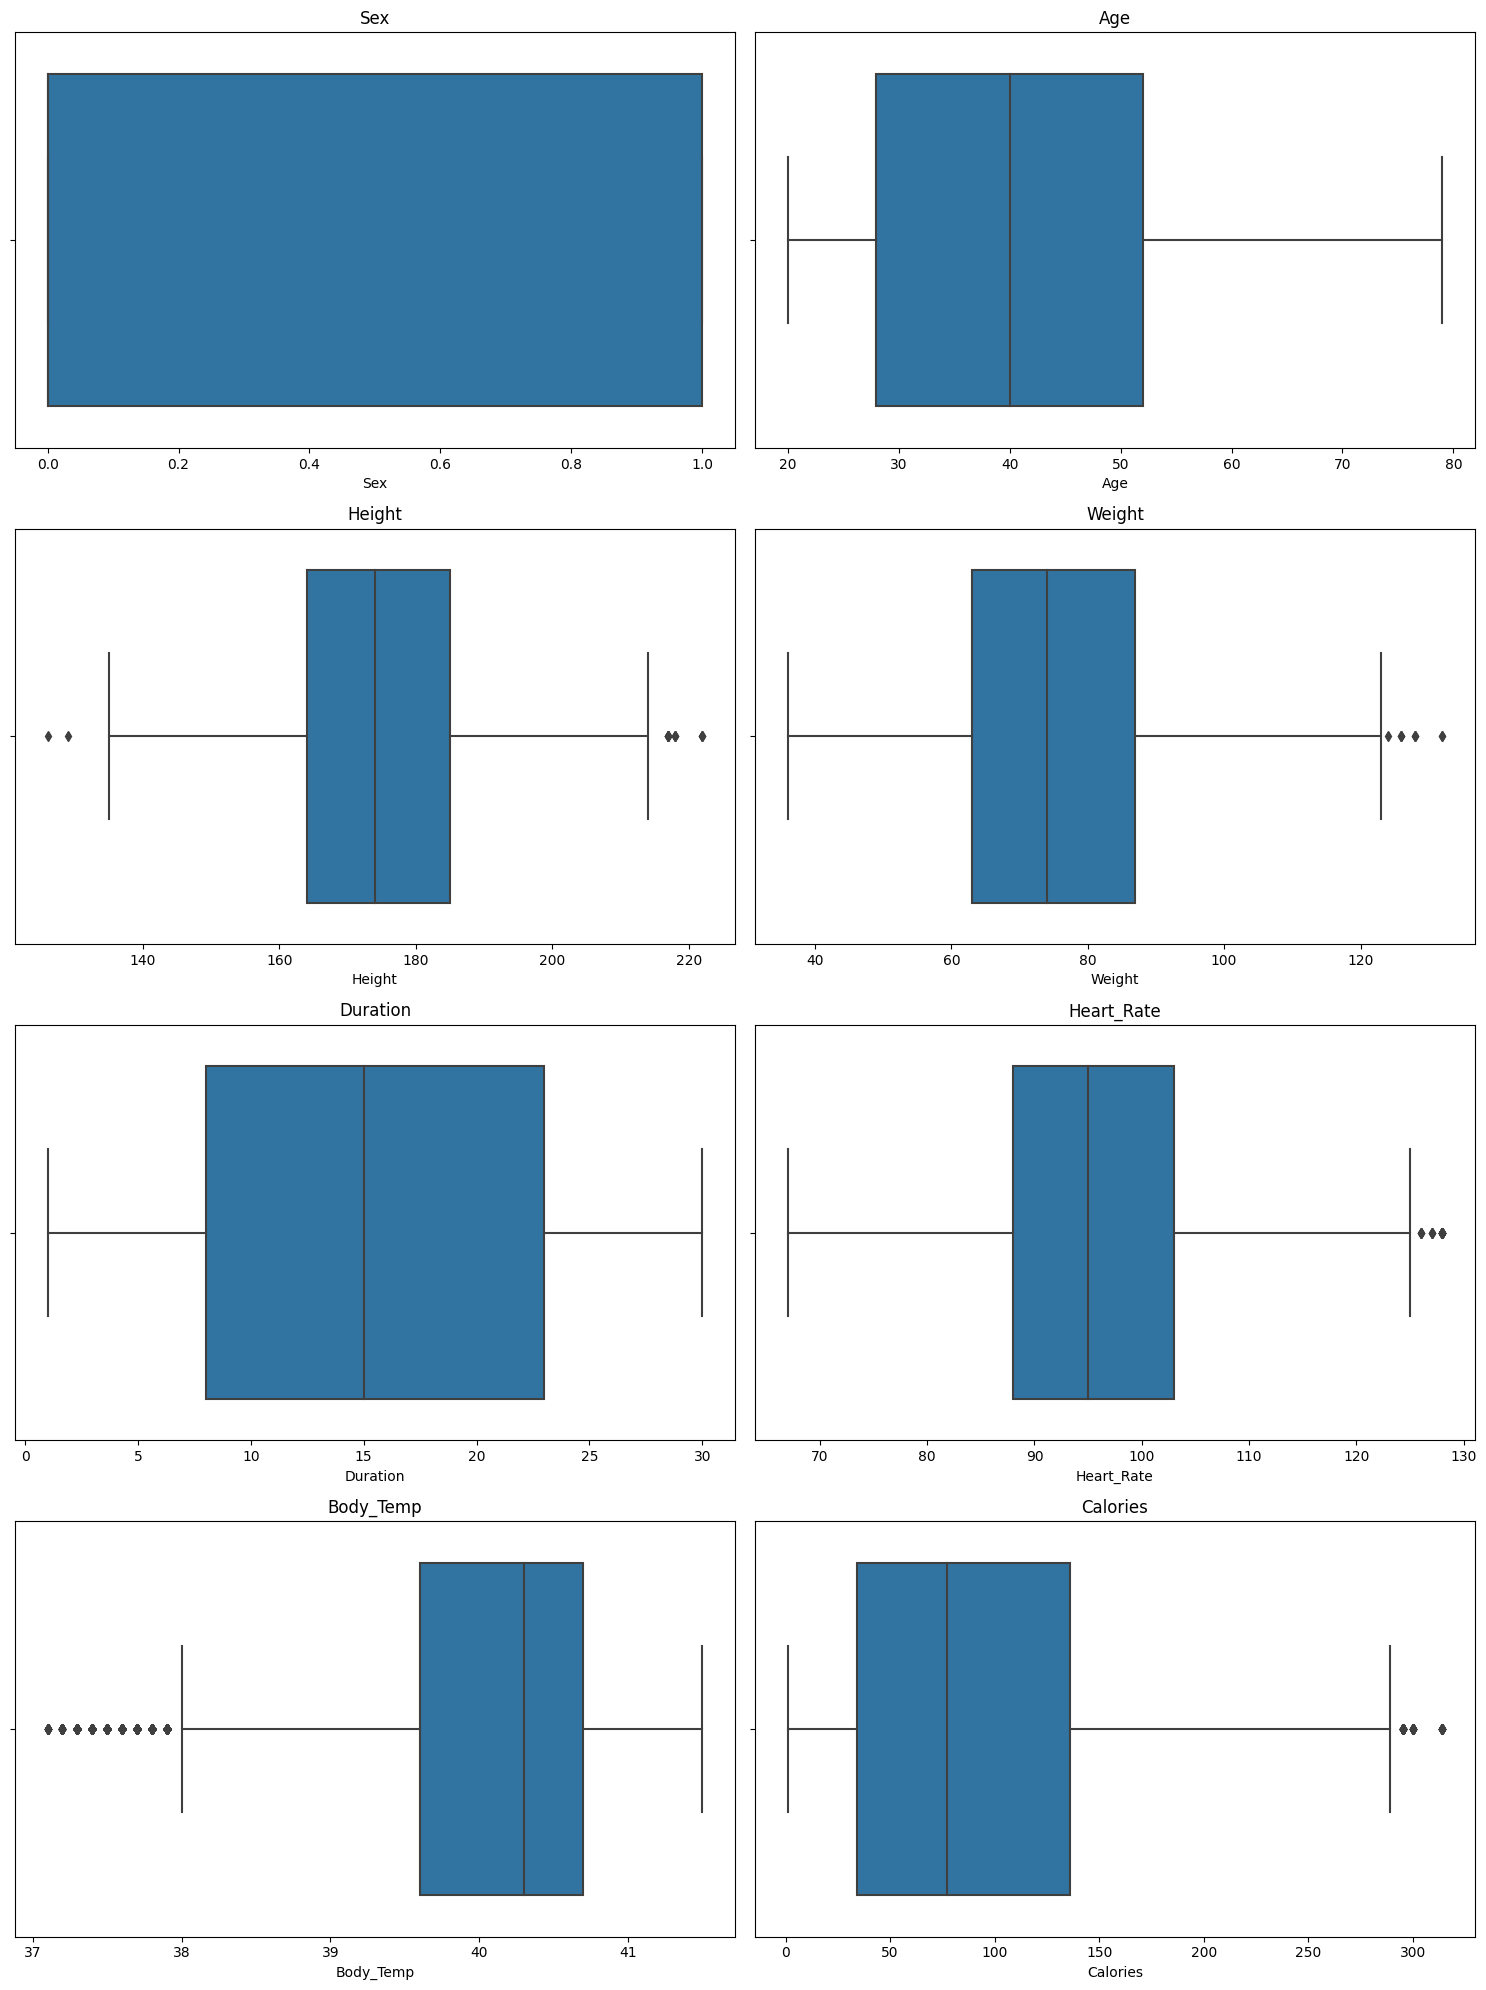

In [12]:
numerical_col=['Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate',
       'Body_Temp']
all_numerical_col=['Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp',
       'Calories']
plt.figure(figsize=(15, 20))

i = 1
for col in all_numerical_col:
    plt.subplot(4, 2, i)
    sns.boxplot(x=df_train[col])
    plt.title(col)
    i += 1

plt.tight_layout()
plt.show()


In [13]:

# for col in numerical_col:
#   q1=df_train[col].quantile(0.25)
#   q3=df_train[col].quantile(0.75)
#   iqr=q3-q1

#   lower_bound=q1-1.5*iqr
#   upper_bound=q3+1.5*iqr
#   df_train=df_train[(df_train[col]> lower_bound) & (df_train[col]<upper_bound)]

# # Remove outliers from df_test
# for col in numerical_col:
#     q1 = df_test[col].quantile(0.25)
#     q3 = df_test[col].quantile(0.75)
#     iqr = q3 - q1

#     lower_bound = q1 - 1.5 * iqr
#     upper_bound = q3 + 1.5 * iqr

#     df_test = df_test[(df_test[col] > lower_bound) & (df_test[col] < upper_bound)]


Sex:  0.0038453481314737795


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Age:  0.4363974756613228


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Height:  0.05177712374068405


...

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Body_Temp:  -1.0223613156737141


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Calories:  0.5391962645229589


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


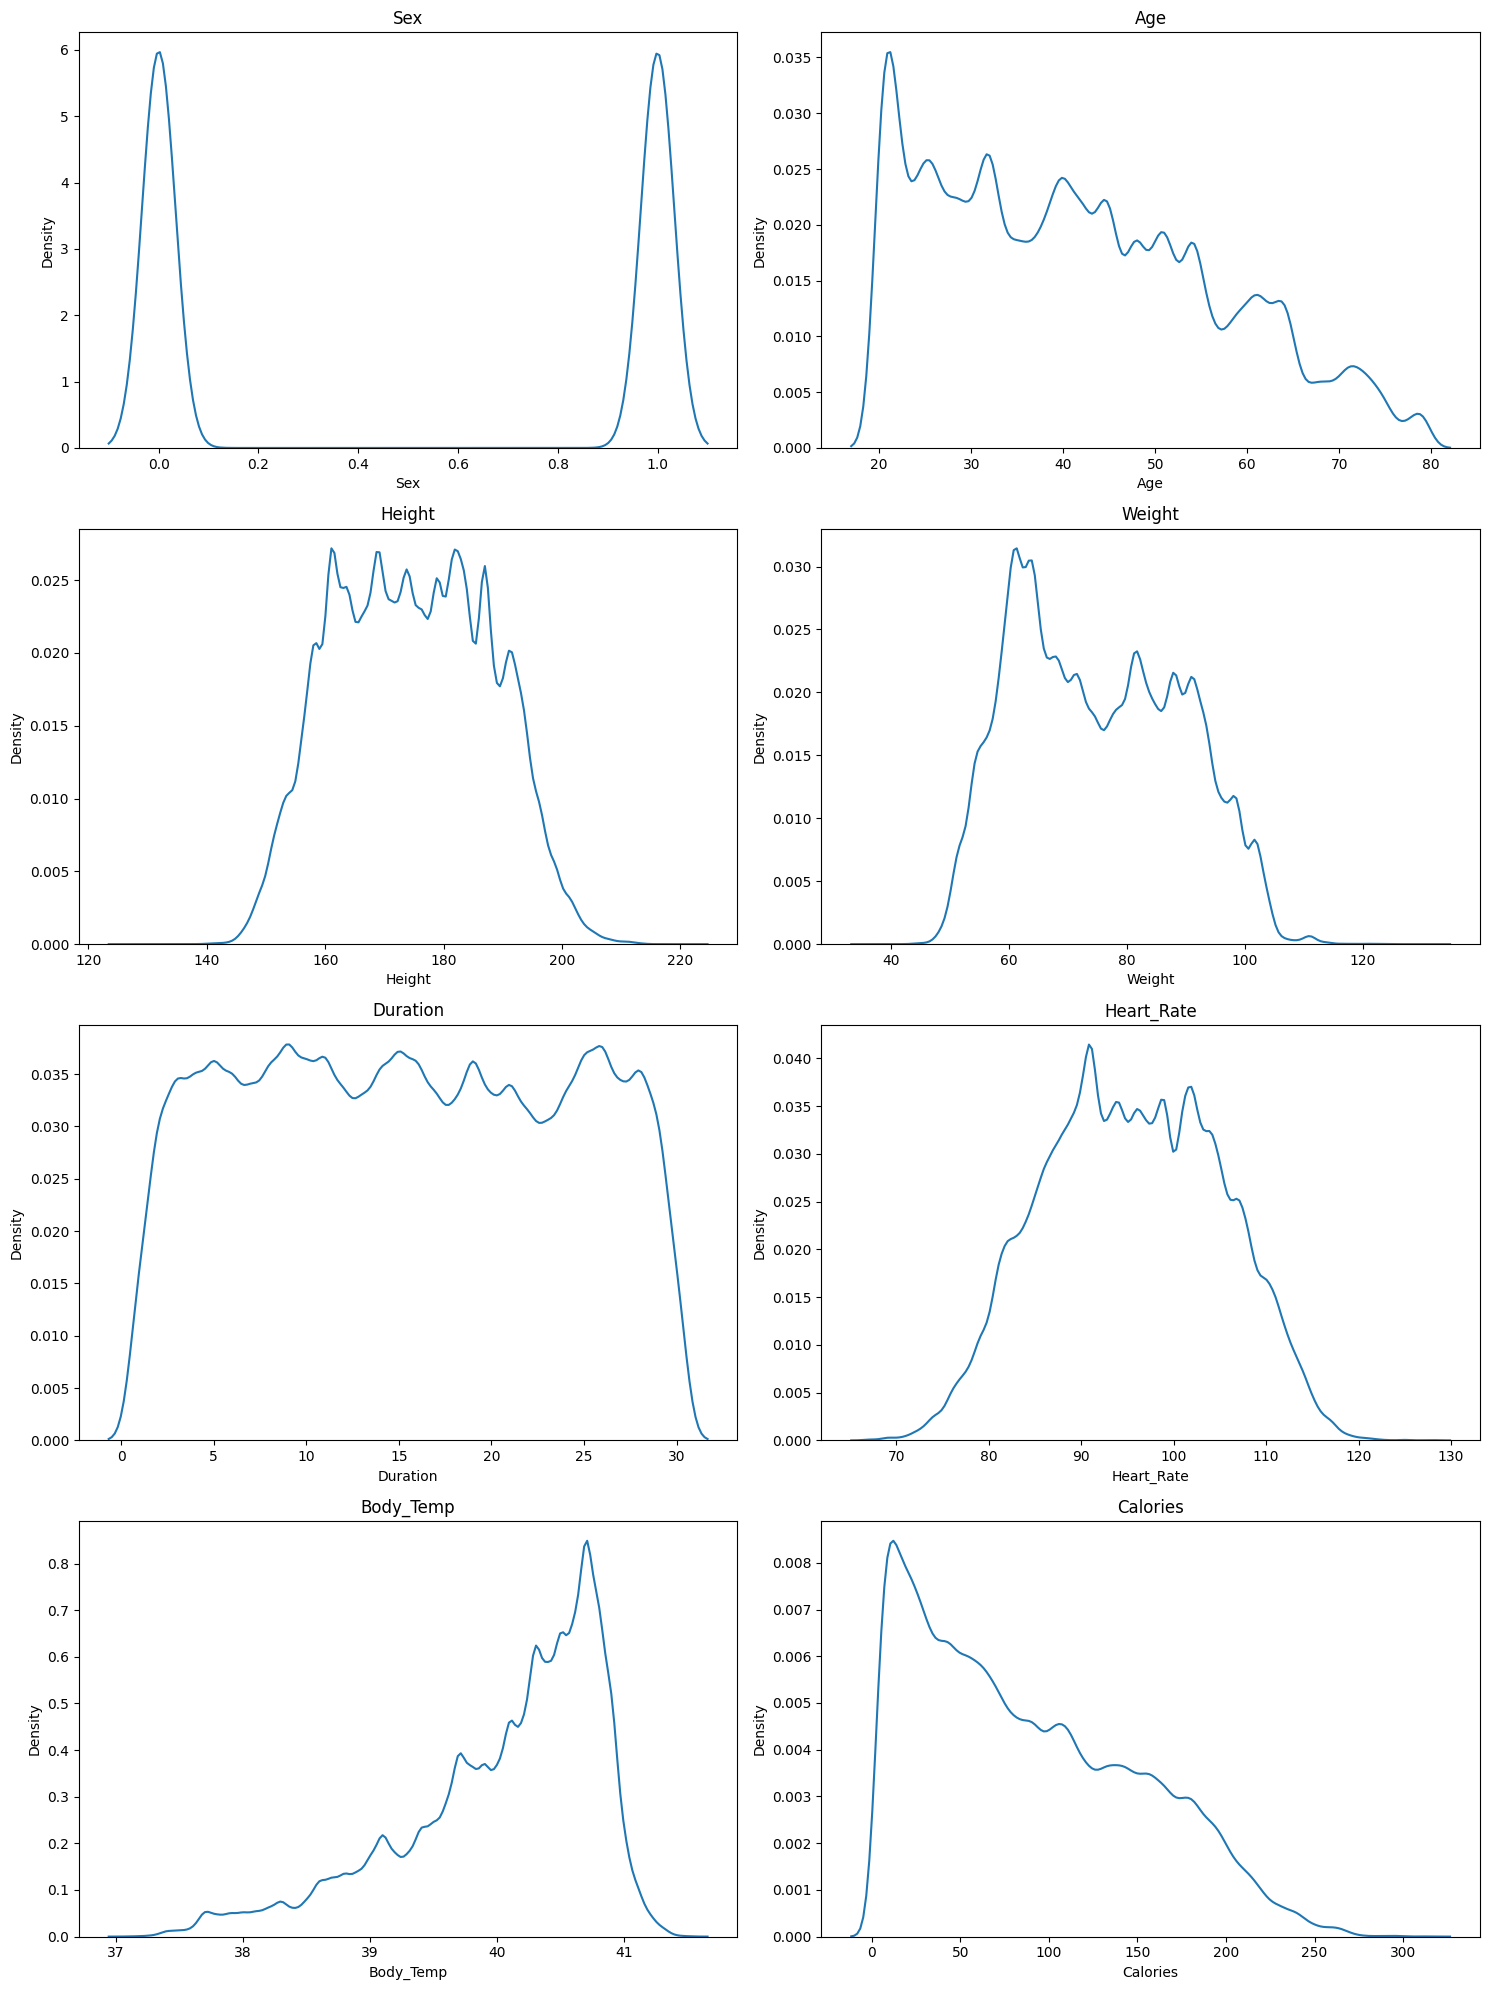

In [14]:
plt.figure(figsize=(15, 20))

i = 1
for col in all_numerical_col:
    print(f'{col}: ',df_train[col].skew())
    plt.subplot(4, 2, i)
    sns.kdeplot(data=df_train,x=df_train[col])
    plt.title(col)
    i += 1

plt.tight_layout()
plt.show()


In [15]:
df_train.info(),df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Sex         750000 non-null  int64  
 1   Age         750000 non-null  int64  
 2   Height      750000 non-null  float64
 3   Weight      750000 non-null  float64
 4   Duration    750000 non-null  float64
 5   Heart_Rate  750000 non-null  float64
 6   Body_Temp   750000 non-null  float64
 7   Calories    750000 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 45.8 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Sex         250000 non-null  int64  
 1   Age         250000 non-null  int64  
 2   Height      250000 non-null  float64
 3   Weight      250000 non-null  float64
 4   Duration    250000 non-null  float64
 5   Heart_Rate

(None, None)

In [16]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()





In [17]:
df_train['Calories'] = np.log1p(df_train['Calories'])
X = df_train.drop('Calories', axis=1)
y = df_train['Calories']

X_test = df_test.copy()

X_scaled=sc.fit_transform(X)
X_test_scaled=sc.transform(X_test)

In [18]:
###practics
xgb_model=XGBRegressor(max_depth=6,n_estimators=1000,learning_rate=0.04,random_state=42)

xgb_model.fit(X_scaled,y)
y_pred_log = xgb_model.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)

y_pred_train_log = xgb_model.predict(X_scaled)
y_pred_train = np.expm1(y_pred_train_log)

rmsle = np.sqrt(mean_squared_log_error(np.expm1(y), y_pred_train))
print(f'RMSLE: {rmsle:.5f}')

RMSLE: 0.05630


In [19]:

model = LGBMRegressor(
    max_depth=6,
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=50,
    feature_fraction=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)


model.fit(X_scaled, y)


y_pred = np.expm1(model.predict(X_test_scaled))
y_train_pred = np.expm1(model.predict(X_scaled))


rmsle = np.sqrt(mean_squared_log_error(np.expm1(y), y_train_pred))
print(f'RMSLE: {rmsle:.5f}')

RMSLE: 0.05734


In [20]:
submission=pd.read_csv('/kaggle/input/playground-series-s5e5/sample_submission.csv')
submission.head(10)

,id,Calories
0,750000,88.283
1,750001,88.283
2,750002,88.283
3,750003,88.283
4,750004,88.283
5,750005,88.283
6,750006,88.283
7,750007,88.283
8,750008,88.283
9,750009,88.283


In [21]:
submission.shape

(250000, 2)

In [22]:
submission = pd.DataFrame({
    'id': submission['id'],
    'Calories': y_pred
})
submission.head(10)

,id,Calories
0,750000,26.957077
1,750001,109.064487
2,750002,86.352752
3,750003,124.170039
4,750004,76.391927
5,750005,21.753856
6,750006,48.575870
7,750007,6.786768
8,750008,10.147688
9,750009,204.688445


In [23]:
submission.shape

(250000, 2)

In [24]:
submission.tail(10)

,id,Calories
249990,999990,5.809035
249991,999991,198.716898
249992,999992,65.101595
249993,999993,38.583602
249994,999994,120.226227
249995,999995,26.228242
249996,999996,9.378076
249997,999997,72.251966
249998,999998,167.718912
249999,999999,75.377440


In [25]:
submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   id        250000 non-null  int64  
 1   Calories  250000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 3.8 MB


In [26]:
submission.to_csv('submission.csv', index=False)